# <center>Trabajo 1 - Análisis espacial de la relación entre la tasa de natalidad y la tasa de alfabetización en la Provincia del Maipo: Comparación censal 2017–2024</center>
### <center><font color="grey">*Helen Aguayo Silva*</font></center>
### <center><font color="grey">*Inteligencia en Datos Geoespaciales*</font></center>
### <center><font color="grey">*Primer semestre 2026*</font></center>

## 1. Introducción
La demografía y la educación constituyen dos dimensiones fundamentales para comprender las dinámicas territoriales de una población. Mientras la tasa de natalidad permite aproximarse al crecimiento demográfico, la tasa de alfabetización refleja el nivel educativo de los habitantes, siendo ambos indicadores relevantes para analizar las condiciones sociales y el desarrollo de un territorio.

En la Provincia del Maipo convergen zonas urbanas, periurbanas y rurales que presentan distintas características demográficas y socioeconómicas. Estas diferencias hacen pertinente estudiar la distribución espacial de ambos indicadores a nivel de zona censal, permitiendo identificar patrones que no son evidentes cuando el análisis se realiza sobre unidades territoriales más agregadas.

El análisis se desarrolla mediante mapas individuales y mapas bivariados elaborados en Python a nivel de zona censal, permitiendo identificar patrones espaciales, permanencias y cambios ocurridos entre los Censos de 2017 y 2024. A partir de ello, se compararán ambos períodos con el fin de aportar al análisis demográfico y a la planificación territorial.

## 2. Objetivos

### Objetivo General
Analizar la relación bivariada entre la tasa de natalidad y la tasa de alfabetización en la Provincia del Maipo, contrastando los datos censales de 2017 y 2024 para identificar patrones de persistencia o cambio territorial.

### Objetivos Específicos
1. Calcular la tasa de natalidad y la tasa de alfabetización para cada zona censal de la Provincia del Maipo utilizando información de los Censos 2017 y 2024.
2. Generar cartografía univariada y bivariada a escala de zona censal que refleje las dinámicas espaciales de ambos indicadores.
3. Interpretar los resultados obtenidos, considerando posibles factores territoriales y sociodemográficos que expliquen la distribución de ambas variables y su utilidad para la planificación territorial.
---
## 3. Pregunta de Análisis
*¿Cómo se relacionan espacialmente la tasa de natalidad y la tasa de alfabetización en las zonas censales de la Provincia del Maipo, y qué cambios presenta esta relación entre los Censos de 2017 y 2024?*

---

## 4. Marco Teórico

### 4.1 Contexto Territorial de la Provincia del Maipo
La Provincia del Maipo se ubica en el sector sur de la Región Metropolitana de Santiago y está conformada por las comunas de San Bernardo, Buin, Paine y Calera de Tango. Debido a su cercanía con la capital, constituye un territorio de transición entre áreas altamente urbanizadas y sectores rurales, presentando una importante diversidad en sus características demográficas, económicas y territoriales.

Durante las últimas décadas, la provincia ha experimentado un importante crecimiento urbano, especialmente en San Bernardo y Buin, producto de la expansión del área metropolitana de Santiago. Paralelamente, comunas como Paine y Calera de Tango conservan una importante superficie destinada a actividades agrícolas y presentan una menor densidad poblacional. Esta combinación de distintos niveles de urbanización genera contrastes que pueden influir en variables demográficas y sociales.

### 4.2 Justificación del Área de Estudio
La Provincia del Maipo constituye un caso de estudio pertinente debido a la heterogeneidad territorial que presenta entre sus distintas zonas censales. La coexistencia de sectores urbanos consolidados, áreas de expansión residencial y espacios predominantemente rurales permite analizar cómo varían los indicadores demográficos y educativos dentro de un mismo contexto provincial.

Asimismo, el análisis a nivel de zona censal visibiliza patrones espaciales inaccesibles cuando la información se encuentra agregada por comuna.

### 4.3 Tasa de Natalidad
Se define como la cantidad de nacimientos vivos que ocurren durante un período determinado en relación con la población objetivo total:

$$\text{Tasa de Natalidad} = \left( \frac{\text{N° de nacimientos vivos}}{\text{Población total objetivo}} \right) \times 1.000$$

Su importancia radica en la información que entrega sobre el crecimiento poblacional, facilitando proyecciones demográficas, migratorias y la planificación de equipamiento e infraestructura social.

### 4.4 Tasa de Alfabetización
La tasa de alfabetización corresponde al porcentaje de la población objetivo que sabe leer y escribir:

$$\text{Tasa de Alfabetización (\%)} = \left( \frac{\text{N° de personas alfabetizadas}}{\text{Total de la población objetivo}} \right) \times 100$$

Permite evaluar las brechas socioeducativas y el acceso histórico a la educación en el territorio.

### 4.5 Relación entre Natalidad y Alfabetización
La literatura demográfica demuestra una estrecha relación entre el nivel educativo y las decisiones reproductivas. Un mayor nivel de alfabetización y educación suele asociarse con un incremento en la planificación familiar, mayor conocimiento sobre salud reproductiva y una posterior postergación de la maternidad, lo que incide directamente en menores tasas de natalidad.

## 5. Metodología
En esta sección se presenta la metodología empleada para el desarrollo del estudio. Se describen la selección de las variables, el procesamiento de los datos y las etapas generales del análisis.

---
### 5.1 Selección de variables
---
***La tasa de natalidad*** constituye uno de los principales indicadores demográficos para analizar la dinámica de crecimiento de una población, ya que permite aproximarse a la intensidad con que se incorporan nuevos habitantes en un territorio. Su distribución espacial puede reflejar diferencias en la estructura por edades, las condiciones socioeconómicas, el acceso a servicios y las características propias de cada zona.

En 2017, al trabajar con microdatos, es posible construir cualquier tramo etario exacto (variable P09, edad en años simples). Sin embargo, la base de datos zonal del Censo 2024 viene pre-agregada por el INE en tramos etarios fijos, siendo el más fino el de 0 a 5 años (n_edad_0_5). No existe la posibilidad de aislar el tramo "0 a 1 año" en 2024. Por esta razón, se optó por construir el indicador con el tramo 0-5 años en ambos años (replicando exactamente ese tramo en 2017 mediante P09 BETWEEN 0 AND 5), sacrificando precisión respecto a nacimientos recientes estrictos, a cambio de asegurar comparabilidad metodológica entre ambos períodos.

Como denominador se utilizó la población total de la zona, y no un subgrupo por sexo/edad (como mujeres en edad fértil), debido a que el dataset 2024 no permite cruces edad-sexo a nivel zonal, solo totales por sexo.

Adicionalmente, se excluyeron del análisis las zonas censales con menos de 30 habitantes, por corresponder a fragmentos de baja representatividad estadística cuyas tasas resultan inestables.

---

***La tasa de alfabetización*** corresponde al porcentaje de personas que saben leer y escribir dentro de la población considerada para este indicador. Más allá de medir una habilidad básica, constituye un reflejo del acceso a la educación y del desarrollo social de un territorio, siendo ampliamente utilizada para evaluar desigualdades y orientar políticas públicas.

Desde una perspectiva territorial, la alfabetización permite identificar diferencias en las condiciones educativas entre distintas zonas censales, las cuales pueden estar asociadas a procesos históricos, características socioeconómicas y niveles de urbanización.

En 2017, se utilizó la variable P15 (nivel del curso más alto aprobado ≥ 5, equivalente a haber completado al menos Educación Básica) sobre la población de 15 años o más, como proxy de alfabetización. En 2024, el dataset zonal entrega directamente la variable n_analfabet (personas de 15 años o más que no saben leer o escribir), pero no incluye una columna de población total de 15 años o más, sino tramos etarios fijos (0-5, 6-13, 14-17, 18-24...). Dado que el tramo 14-17 no permite aislar exactamente los 15+, se aproximó la población de referencia como población total − población 0-5 − población 6-13, lo que en la práctica corresponde a población de 14 años o más. Esto introduce una leve sobreestimación del universo (incluye a personas de 14 años, que no deberían contarse), lo que podría subestimar levemente la tasa real de alfabetización de 2024 respecto a la definición estricta. Esta limitación se documenta explícitamente y no afecta significativamente la comparación relativa entre zonas dentro de un mismo año.

---
**A continuación, se detalla en código el paso a paso del desarrollo del trabajo:**

# *Librerías*

In [5]:
# Librerías para mapas 2017
! pip install pyreadr
!conda install -y pyarrow
!conda install sqlalchemy
!pip install psycopg2-binary
from sqlalchemy import create_engine
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import mapclassify 
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
# Librerías para mapas 2024
import numpy as np
import matplotlib.pyplot as plt
import pyreadr

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




# *2017*

### En esta sección, se deja la metodología y resultados del tratamiento de los datos del Censo 2017.

Primero, se "llama" a la base de datos creada en pgAdmin.

In [12]:
DB_HOST     = 'localhost'
DB_PORT     = 5432
DB_NAME     = 'censo_rm'
DB_USER     = 'postgres'
DB_PASSWORD = 'postgres'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

Posteriormente, se elabora un código que nos ayuda a formar nuestras variables.

In [13]:
sql_indicadores = '''
WITH agg AS (
SELECT 
c.nom_comuna, 
z.geocodigo::DOUBLE PRECISION AS geocodigo,

ROUND((COUNT(*) FILTER (WHERE p.p15 >= 5 AND p.p09 >= 15) * 100.0) / NULLIF(COUNT(*) FILTER (WHERE p.p09 >= 15), 0), 2) AS tasa_alfabetizacion,

ROUND((COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 5) * 100.0) / NULLIF(COUNT(*), 0), 2) AS tasa_natalidad

FROM public.personas AS p
JOIN public.hogares AS h 
ON p.hogar_ref_id = h.hogar_ref_id
JOIN public.viviendas AS v 
ON h.vivienda_ref_id = v.vivienda_ref_id
JOIN public.zonas AS z 
ON v.zonaloc_ref_id = z.zonaloc_ref_id
JOIN public.comunas AS c 
ON z.codigo_comuna = c.codigo_comuna
JOIN public.provincias AS pr 
ON pr.provincia_ref_id = c.provincia_ref_id
WHERE pr.nom_provincia = 'MAIPO'
GROUP BY c.nom_comuna, z.geocodigo
)
SELECT a.*, shp.geom
FROM agg AS a
JOIN dpa.zonas_censales_rm AS shp 
ON shp.geocodigo = a.geocodigo;
'''

Para cerciorarnos de que el código está bien, visualizamos las columnas resultantes:

In [14]:
gdf = gpd.read_postgis(sql_indicadores, engine, geom_col='geom')

In [15]:
gdf

,nom_comuna,geocodigo,tasa_alfabetizacion,tasa_natalidad,geom
0,BUIN,1.340201e+10,99.07,7.14,"MULTIPOLYGON (((338473.969 6267089, 338495.031..."
1,BUIN,1.340201e+10,99.74,5.87,"MULTIPOLYGON (((337995.5 6266616, 338055.781 6..."
2,BUIN,1.340201e+10,99.52,5.69,"MULTIPOLYGON (((339976.281 6266813.823, 339902..."
3,BUIN,1.340201e+10,99.70,10.60,"MULTIPOLYGON (((337132.548 6266377.495, 337183..."
4,BUIN,1.340201e+10,99.87,10.56,"MULTIPOLYGON (((338555.313 6265882.5, 338648.0..."
...,...,...,...,...,...
215,SAN BERNARDO,1.340114e+10,99.65,8.06,"MULTIPOLYGON (((343175.806 6279405.6, 343146.9..."
216,SAN BERNARDO,1.340114e+10,99.90,13.65,"MULTIPOLYGON (((342639.351 6276424.567, 342643..."
217,SAN BERNARDO,1.340114e+10,99.77,12.41,"MULTIPOLYGON (((343961.782 6278561.663, 343987..."
218,SAN BERNARDO,1.340114e+10,99.67,10.55,"MULTIPOLYGON (((344034.25 6278632.569, 344051...."


Para tener un mejor entenidimiento del comportamiento de las variables, las graficamos:

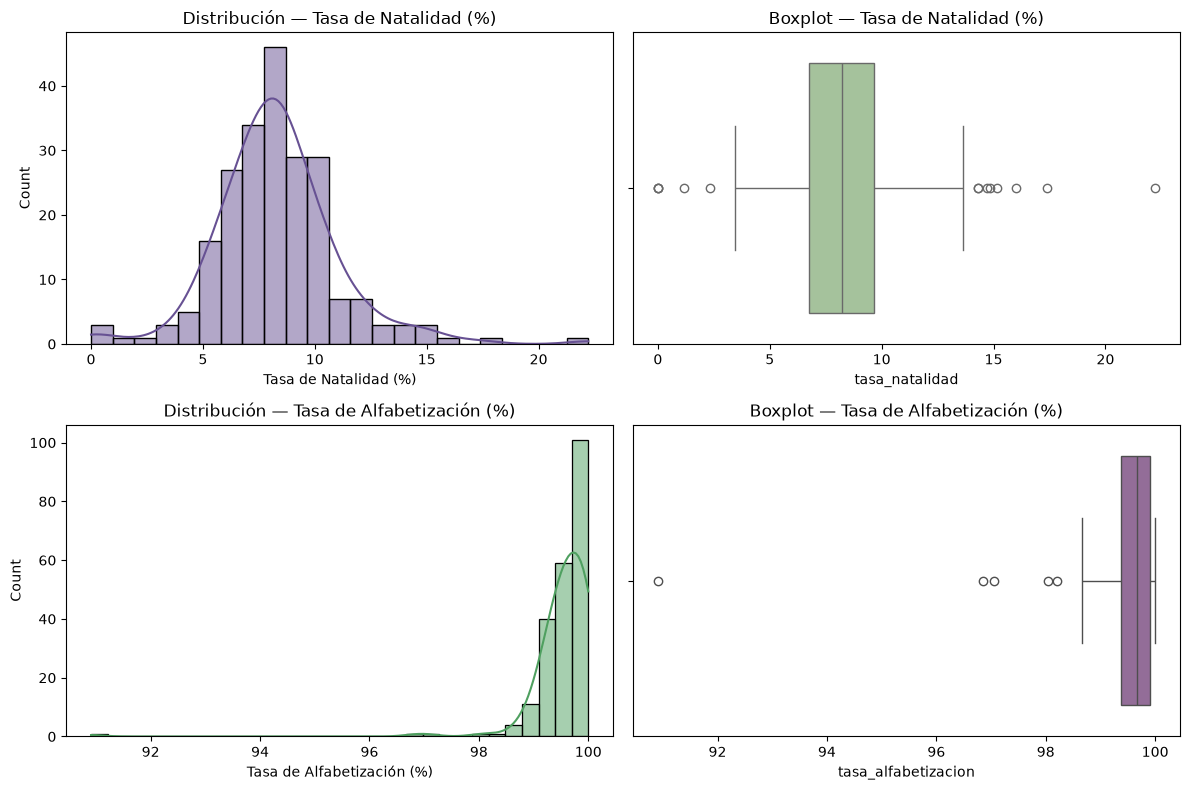

       tasa_natalidad  tasa_alfabetizacion
count          220.00               220.00
mean             8.28                99.55
std              2.74                 0.73
min              0.00                90.91
25%              6.74                99.38
50%              8.24                99.66
75%              9.66                99.90
max             22.22               100.00


In [21]:
from scipy.stats import pearsonr

# --- Univariados: histograma + boxplot para cada variable ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(gdf_maipo['tasa_natalidad'], kde=True, color='#675193', ax=axes[0,0])
axes[0,0].set_title('Distribución — Tasa de Natalidad (%)')
axes[0,0].set_xlabel('Tasa de Natalidad (%)')

sns.boxplot(x=gdf_maipo['tasa_natalidad'], color='#a2c896', ax=axes[0,1])
axes[0,1].set_title('Boxplot — Tasa de Natalidad (%)')

sns.histplot(gdf_maipo['tasa_alfabetizacion'], kde=True, color='#4fa060', ax=axes[1,0])
axes[1,0].set_title('Distribución — Tasa de Alfabetización (%)')
axes[1,0].set_xlabel('Tasa de Alfabetización (%)')

sns.boxplot(x=gdf_maipo['tasa_alfabetizacion'], color='#98669f', ax=axes[1,1])
axes[1,1].set_title('Boxplot — Tasa de Alfabetización (%)')

plt.tight_layout()
plt.show()

print(gdf_maipo[['tasa_natalidad', 'tasa_alfabetizacion']].describe().round(2))

**Tasa de natalidad**

El histograma de la tasa de natalidad para ambos años muestra una distribución aproximadamente unimodal, concentrándose la mayor parte de las zonas censales entre valores cercanos al 5 % y 7 %. Esto indica que, en la Provincia del Maipo, la mayoría de las zonas presenta niveles relativamente similares de natalidad estimada, mientras que solo unas pocas registran valores considerablemente mayores o menores.

Los diagramas de caja muestran una dispersión moderada y la presencia de algunos valores atípicos. En particular, para el año 2024 se observa un valor extremo cercano al 0 %, correspondiente a zonas censales con una población muy reducida. Debido al bajo número de habitantes en estas unidades territoriales, la tasa calculada resulta poco representativa y debe interpretarse con cautela, ya que pequeñas variaciones en la población producen cambios importantes en el indicador.

--- 
**Tasa de alfabetización**

La distribución de la tasa de alfabetización presenta una fuerte concentración hacia valores altos, principalmente entre 97 % y 99 %, evidenciando que la mayor parte de las zonas censales posee elevados niveles de alfabetización.

Los boxplots muestran una variabilidad relativamente baja, con algunos valores atípicos asociados a zonas con porcentajes inferiores al promedio provincial. En términos generales, el indicador presenta una distribución más homogénea que la tasa de natalidad, lo que refleja menores diferencias territoriales en el acceso a las habilidades básicas de lectura y escritura.

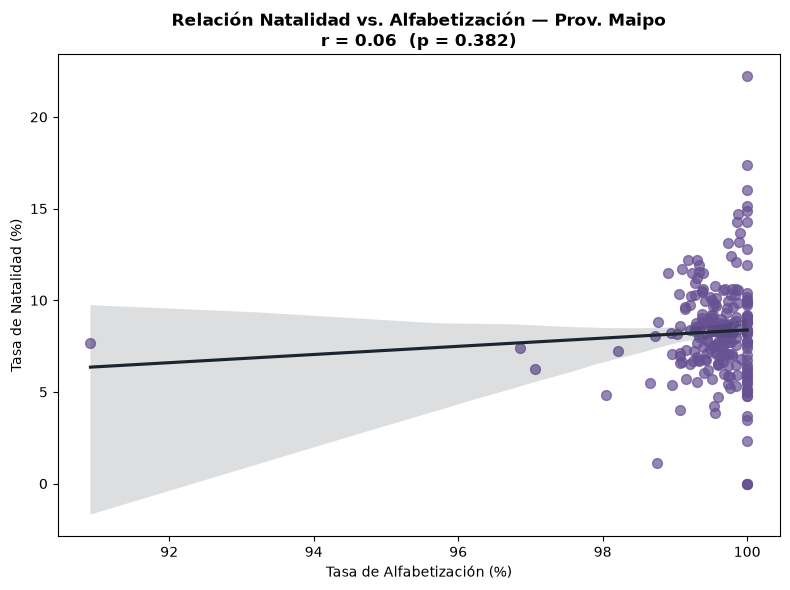

In [22]:
# --- Bivariado: relación entre ambas tasas ---
r, p_value = pearsonr(gdf_maipo['tasa_alfabetizacion'], gdf_maipo['tasa_natalidad'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=gdf_maipo, x='tasa_alfabetizacion', y='tasa_natalidad',
    scatter_kws={'color': '#675193', 'alpha': 0.7, 's': 50},
    line_kws={'color': '#1a252f'}, ax=ax
)
ax.set_title(
    f'Relación Natalidad vs. Alfabetización — Prov. Maipo\nr = {r:.2f}  (p = {p_value:.3f})',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tasa de Alfabetización (%)')
ax.set_ylabel('Tasa de Natalidad (%)')
plt.tight_layout()
plt.show()

El gráfico de dispersión muestra una tendencia negativa entre la tasa de alfabetización y la tasa de natalidad estimada. A medida que aumentan los niveles de alfabetización, las tasas de natalidad tienden a disminuir ligeramente, aunque la dispersión de los puntos indica que la relación no es perfectamente lineal.

La presencia de una pendiente negativa sugiere una asociación inversa entre ambas variables, consistente con la hipótesis planteada en el estudio. Sin embargo, la variabilidad observada evidencia que la alfabetización no explica por sí sola las diferencias en natalidad entre zonas censales, por lo que otros factores territoriales y sociodemográficos también podrían influir en el patrón observado.

### Antes de pasar a los mapas de las variables, se deja el mapa de la provincia para tener una noción previa de como luce:

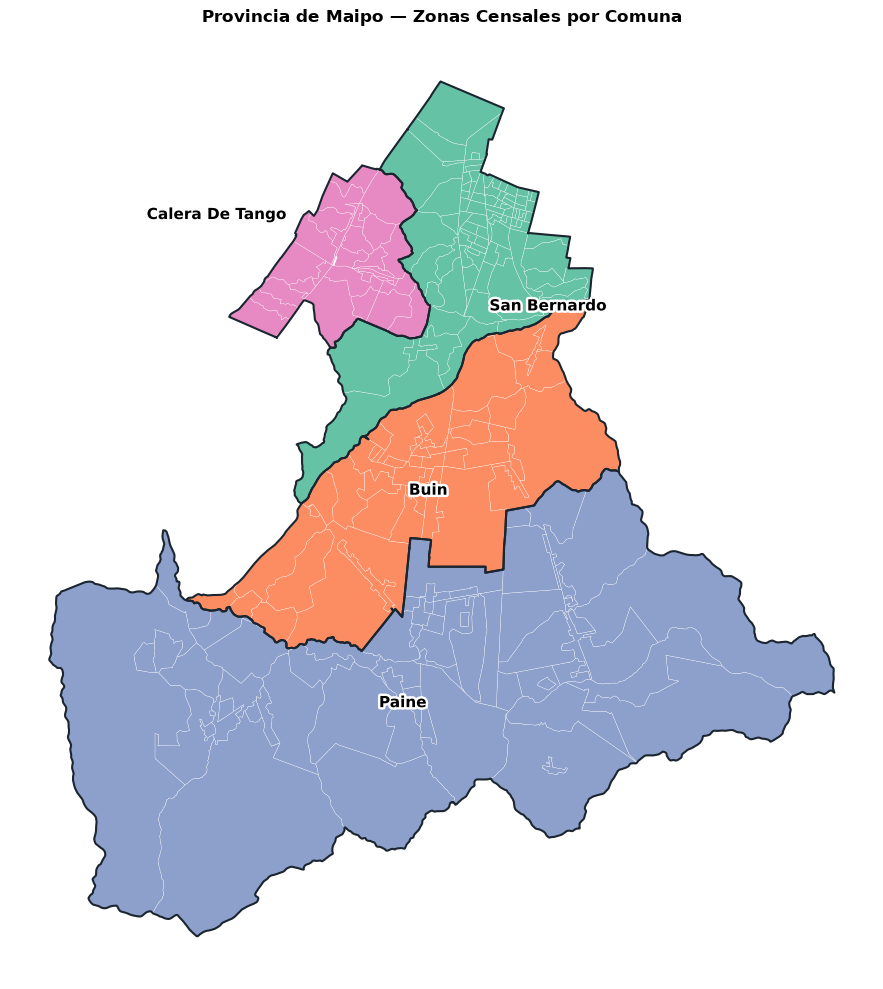

In [17]:
# 1. Filtrar comunas de Maipo
comunas_maipo = ['SAN BERNARDO', 'BUIN', 'PAINE', 'CALERA DE TANGO']
gdf_maipo = gdf[gdf['nom_comuna'].str.upper().isin(comunas_maipo)].copy()

# 2. Eliminar líneas/geometrías internas y reparar huecos
gdf_maipo = gdf_maipo[
    gdf_maipo['geom'].geom_type.isin(['Polygon', 'MultiPolygon'])
]

# 3. Crear figura
fig, ax = plt.subplots(figsize=(10, 10))

# 4. Asignar colores por comuna
paleta = sns.color_palette('Set2', n_colors=4)
colores_comuna = dict(zip(comunas_maipo, paleta))
gdf_maipo['color_comuna'] = (
    gdf_maipo['nom_comuna'].str.upper().map(colores_comuna)
)

# 5. Dibujar Zonas Censales
gdf_maipo.plot(
    ax=ax, color=gdf_maipo['color_comuna'], edgecolor='white', linewidth=0.2
)

# 6. Disolver comunas y dibujar SOLAMENTE el perímetro exterior 
comunas = gdf_maipo.dissolve(by='nom_comuna', as_index=False)

# Extraer y dibujar solo el contorno exterior envolvente de cada comuna
for _, row in comunas.iterrows():
    geom = row['geom']
    # Si es MultiPolygon tomamos los exteriores de cada polígono
    poligonos = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
    for poly in poligonos:
        x_ext, y_ext = poly.exterior.xy
        ax.plot(x_ext, y_ext, color='#1a252f', linewidth=1.5)

# 7. Desplazamientos directos para nombres
offsets = {
    'CALERA DE TANGO': (-8000, 3000),
    'SAN BERNARDO': (6000, -2000),
}

if gdf_maipo.crs and gdf_maipo.crs.is_geographic:
    offsets = {'CALERA DE TANGO': (-0.08, 0.03), 'SAN BERNARDO': (0.06, -0.02)}

# 8. Texto con halo blanco
for _, row in comunas.iterrows():
    nombre = row['nom_comuna'].upper()
    c = row['geom'].centroid

    dx, dy = offsets.get(nombre, (0, 0))
    x, y = c.x + dx, c.y + dy

    ax.text(
        x,
        y,
        row['nom_comuna'].title(),
        ha='center',
        va='center',
        weight='bold',
        fontsize=11,
    ).set_path_effects([pe.withStroke(linewidth=3.5, foreground='white')])

# 9. Título y formato (sin simbología)
ax.set_title(
    'Provincia de Maipo — Zonas Censales por Comuna', weight='bold', pad=12
)
ax.axis('off')

plt.tight_layout()
plt.show()

Se realizaron mapas individuales para cada variable elegida:

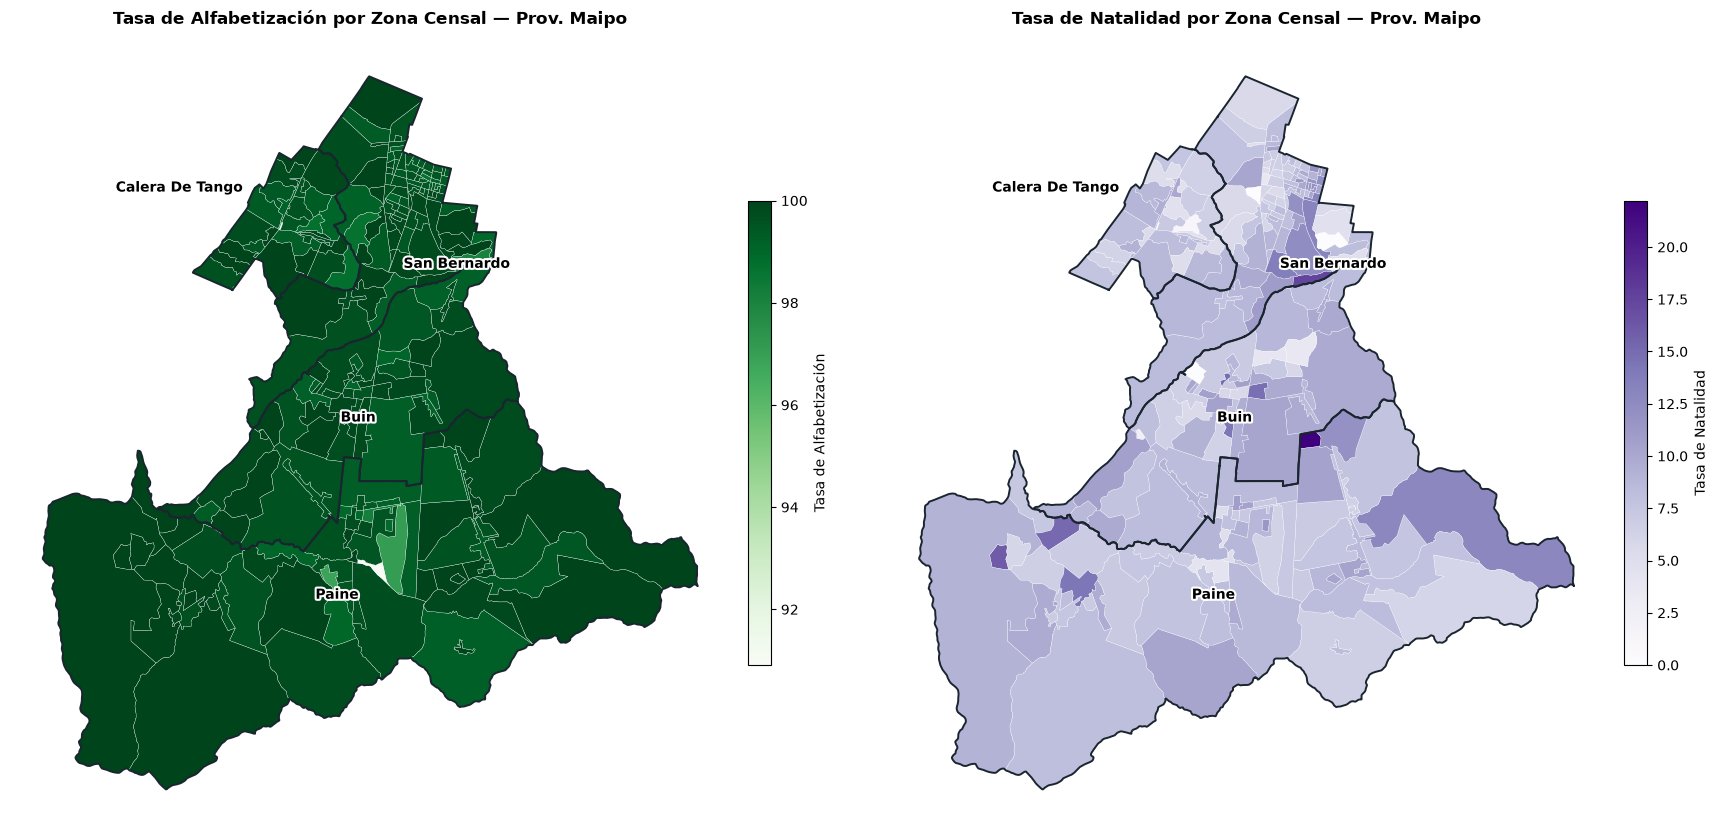

In [18]:
# 1. Filtrar los datos para la Provincia de Maipo
comunas_maipo = ['SAN BERNARDO', 'BUIN', 'PAINE', 'CALERA DE TANGO']
gdf_maipo = gdf[gdf['nom_comuna'].str.upper().isin(comunas_maipo)].copy()

# 2. Filtro anti-líneas / geometrías no válidas
gdf_maipo = gdf_maipo[
    gdf_maipo['geom'].geom_type.isin(['Polygon', 'MultiPolygon'])
]

# 3. Disolver comunas para obtener límites exteriores y centroides
comunas = gdf_maipo.dissolve(by='nom_comuna', as_index=False)

# Desplazamientos personalizados para evitar choque de etiquetas
offsets = {
    'CALERA DE TANGO': (-8000, 3000),
    'SAN BERNARDO': (6000, -2000),
}
if gdf_maipo.crs and gdf_maipo.crs.is_geographic:
    offsets = {'CALERA DE TANGO': (-0.08, 0.03), 'SAN BERNARDO': (0.06, -0.02)}


# 4. Función de mapeo univariado con nuestro estilo limpio
def plot_univariado_estilo(ax, gdf_z, gdf_c, col, cmap, titulo, cbar_label):
    # A. Mapa de coropletas por zona censal
    gdf_z.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        linewidth=0.2,
        edgecolor='white',
        legend=True,
        legend_kwds={'label': cbar_label, 'shrink': 0.55, 'pad': 0.02},
    )

    # B. Dibujar ÚNICAMENTE el borde exterior de las comunas (estilo perimetral limpio)
    for _, row in gdf_c.iterrows():
        geom = row['geom']
        poligonos = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
        for poly in poligonos:
            x_ext, y_ext = poly.exterior.xy
            ax.plot(x_ext, y_ext, color='#1a252f', linewidth=1.4)

    # C. Nombres de las comunas con halo blanco
    for _, row in gdf_c.iterrows():
        nombre = row['nom_comuna'].upper()
        c = row['geom'].centroid

        dx, dy = offsets.get(nombre, (0, 0))
        x, y = c.x + dx, c.y + dy

        ax.text(
            x,
            y,
            row['nom_comuna'].title(),
            ha='center',
            va='center',
            weight='bold',
            fontsize=10,
        ).set_path_effects([pe.withStroke(linewidth=3, foreground='white')])

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=12)
    ax.axis('off')


# 5. Crear la figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#ffffff')

# Mapa 1: Tasa de Alfabetización
plot_univariado_estilo(
    axes[0],
    gdf_maipo,
    comunas,
    col='tasa_alfabetizacion',
    cmap='Greens',
    titulo='Tasa de Alfabetización por Zona Censal — Prov. Maipo',
    cbar_label='Tasa de Alfabetización',
)

# Mapa 2: Tasa de Natalidad
plot_univariado_estilo(
    axes[1],
    gdf_maipo,
    comunas,
    col='tasa_natalidad',
    cmap='Purples',
    titulo='Tasa de Natalidad por Zona Censal — Prov. Maipo',
    cbar_label='Tasa de Natalidad',
)

plt.tight_layout(pad=2)
plt.show()

**Tasa de natalidad**

El mapa de la tasa de natalidad para 2017 evidencia una mayor heterogeneidad espacial en comparación con la alfabetización. Se observan zonas censales con tasas más elevadas distribuidas de manera puntual en distintos sectores de la provincia, mientras que otras presentan valores moderados o bajos.

Este patrón sugiere que la natalidad no se concentra exclusivamente en un único núcleo territorial, sino que responde a dinámicas locales asociadas a la estructura etaria, las características socioeconómicas y el grado de urbanización de cada zona censal. La variabilidad observada refleja que la incorporación reciente de población no ocurre de forma uniforme dentro de la Provincia del Maipo.

---
**Tasa de alfabetización**

El mapa de la tasa de alfabetización para el año 2017 muestra una distribución relativamente homogénea en la Provincia del Maipo, predominando zonas censales con valores elevados de alfabetización. Los tonos más intensos se concentran principalmente en sectores urbanos, especialmente en áreas asociadas a San Bernardo y Buin, lo que sugiere un mayor acceso a servicios educativos y una mayor consolidación urbana.

Por otro lado, algunas zonas periféricas y rurales presentan valores ligeramente inferiores, evidenciando diferencias territoriales en las condiciones educativas. No obstante, incluso estos sectores mantienen niveles de alfabetización relativamente altos, lo que indica que la provincia, en términos generales, presenta una buena cobertura de habilidades básicas de lectura y escritura.

---

Y posteriormente se hizo un gráfico bivariado para ver el comportamiento entre estas:

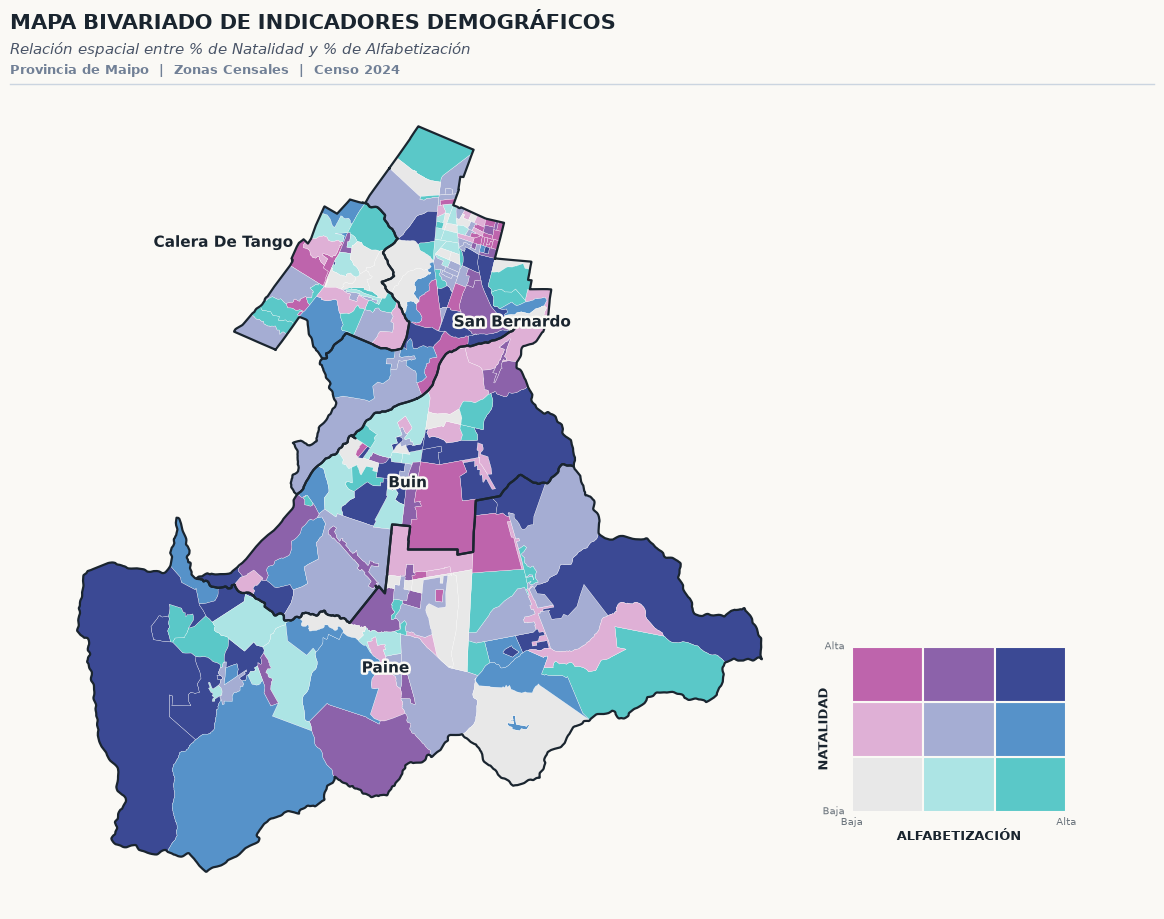

In [31]:
# -------------------------------------------------------------
# 1. CLASIFICACIÓN Y ASIGNACIÓN DE COLORES BIVARIADOS
# -------------------------------------------------------------
color_matrix = np.array([
    ['#e8e8e8', '#ace4e4', '#5ac8c8'],  # Natalidad Baja (Alf: Baja, Med, Alta)
    ['#dfb0d6', '#a5add3', '#5692c9'],  # Natalidad Media
    ['#be64ac', '#8c62aa', '#3b4994']   # Natalidad Alta
])

# Crear terciles (0, 1, 2)
gdf['cat_natalidad'] = pd.qcut(gdf['tasa_natalidad'], q=3, labels=[0, 1, 2], duplicates='drop').astype(int)
gdf['cat_alfabetizacion'] = pd.qcut(gdf['tasa_alfabetizacion'], q=3, labels=[0, 1, 2], duplicates='drop').astype(int)

# Mapear colores bivariados a las zonas censales
gdf['color_bivariado'] = [
    color_matrix[nat][alf] 
    for nat, alf in zip(gdf['cat_natalidad'], gdf['cat_alfabetizacion'])
]

# Filtrar geometrías válidas
gdf_maipo = gdf[gdf['geom'].geom_type.isin(['Polygon', 'MultiPolygon'])].copy()

# -------------------------------------------------------------
# 2. CONFIGURACIÓN DE LA FIGURA Y LIENZO
# -------------------------------------------------------------
fig = plt.figure(figsize=(13, 10), facecolor='#FAF9F5')

# Eje del mapa principal
ax = fig.add_axes([0.05, 0.05, 0.65, 0.82], facecolor='#FAF9F5')
ax.axis('off')

# -------------------------------------------------------------
# 3. DIBUJAR ZONAS Y CONTORNOS EXTERIORES LIMPIOS
# -------------------------------------------------------------
gdf_maipo.plot(
    ax=ax, 
    color=gdf_maipo['color_bivariado'], 
    edgecolor='white', 
    linewidth=0.2,
    zorder=1
)

comunas = gdf_maipo.dissolve(by='nom_comuna', as_index=False)

for _, row in comunas.iterrows():
    geom = row['geom']
    poligonos = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
    for poly in poligonos:
        x_ext, y_ext = poly.exterior.xy
        ax.plot(x_ext, y_ext, color='#1a252f', linewidth=1.6, zorder=2)

# -------------------------------------------------------------
# 4. ETIQUETAS CON HALO BLANCO (Tu método exacto de desplazamiento)
# -------------------------------------------------------------
offsets = {
    'CALERA DE TANGO': (-8000, 3000),
    'SAN BERNARDO': (6000, -2000),
}

if gdf_maipo.crs and gdf_maipo.crs.is_geographic:
    offsets = {'CALERA DE TANGO': (-0.08, 0.03), 'SAN BERNARDO': (0.06, -0.02)}

for _, row in comunas.iterrows():
    nombre = row['nom_comuna'].upper()
    c = row['geom'].centroid

    dx, dy = offsets.get(nombre, (0, 0))
    x, y = c.x + dx, c.y + dy

    ax.text(
        x, y,
        row['nom_comuna'].title(),
        ha='center', va='center',
        weight='bold', fontsize=11,
        color='#1a252f',
        zorder=3
    ).set_path_effects([pe.withStroke(linewidth=3.5, foreground='#FAF9F5')])

# -------------------------------------------------------------
# 5. LEYENDA BIVARIADA MEJORADA
# -------------------------------------------------------------
ax_leg = fig.add_axes([0.68, 0.12, 0.22, 0.22], facecolor='#FAF9F5')
ax_leg.axis('off')

# Dibujar la matriz 3x3
for i in range(3):
    for j in range(3):
        ax_leg.add_patch(
            plt.Rectangle((j, i), 1, 1, facecolor=color_matrix[i][j], edgecolor='#FAF9F5', lw=1.5)
        )

ax_leg.set_xlim(-0.5, 3.5)
ax_leg.set_ylim(-0.5, 3.5)

# Textos de los ejes en la leyenda
ax_leg.text(1.5, -0.3, 'ALFABETIZACIÓN', ha='center', va='top', fontsize=9, fontweight='bold', color='#1a252f')
ax_leg.text(0, -0.1, 'Baja', ha='center', va='top', fontsize=7.5, color='#6C757D')
ax_leg.text(3, -0.1, 'Alta', ha='center', va='top', fontsize=7.5, color='#6C757D')

ax_leg.text(-0.3, 1.5, 'NATALIDAD', ha='right', va='center', rotation=90, fontsize=9, fontweight='bold', color='#1a252f')
ax_leg.text(-0.1, 0, 'Baja', ha='right', va='center', fontsize=7.5, color='#6C757D')
ax_leg.text(-0.1, 3, 'Alta', ha='right', va='center', fontsize=7.5, color='#6C757D')

# -------------------------------------------------------------
# 6. ENCABEZADO Y TÍTULO
# -------------------------------------------------------------
fig.text(0.06, 0.93, 'MAPA BIVARIADO DE INDICADORES DEMOGRÁFICOS', fontsize=15, fontweight='bold', color='#1a252f')
fig.text(0.06, 0.905, 'Relación espacial entre % de Natalidad y % de Alfabetización', fontsize=11, fontstyle='italic', color='#4A5568')
fig.text(0.06, 0.885, 'Provincia de Maipo  |  Zonas Censales  |  Censo 2024', fontsize=9, fontweight='bold', color='#718096')

# Línea divisoria decorativa
fig.add_artist(plt.Line2D([0.06, 0.94], [0.875, 0.875], color='#CBD5E0', linewidth=1))

plt.show()

El mapa bivariado de 2017 permite observar la relación espacial entre la tasa de natalidad y la tasa de alfabetización. Predominan zonas con niveles altos de alfabetización combinados con tasas de natalidad medias o bajas, especialmente en sectores urbanos de la provincia. También se identifican algunas zonas donde una alta alfabetización coexiste con tasas relativamente elevadas de natalidad, lo que indica que la relación entre ambas variables no es uniforme en todo el territorio.

La distribución de las categorías bivariadas sugiere una tendencia general hacia la coexistencia de mayor alfabetización y menor natalidad, aunque existen excepciones locales que podrían estar asociadas a diferencias socioeconómicas y demográficas entre zonas censales.

# *2024*

## Ahora, se realizarán los mapas correspondientes a las tasas obtenidas del Censo 2024.

Llamamos a la base de datos del Censo 2024, que al ser un archivo -parquet se maneja distinto que la del Censo 2017 que son microdatos:

In [32]:
gdf24 = gpd.read_parquet('Cartografía_censo2024_R13_Zonal.parquet')
gdf24_maipo = gdf24[gdf24['PROVINCIA'] == 'MAIPO'].copy()

print(gdf24_maipo.shape)          # (114, ...) → Buin, Paine, San Bernardo, Calera de Tango
print(gdf24_maipo['COMUNA'].unique())

# Cálculo de tasas con Censo 2024
# Natalidad: 0-5 años / población total
gdf24_maipo['tasa_natalidad'] = (gdf24_maipo['n_edad_0_5'] / gdf24_maipo['n_per']) * 100

# Alfabetización: aproximación de población 15+ 
gdf24_maipo['pob_15_mas_aprox'] = (
    gdf24_maipo['n_per'] - gdf24_maipo['n_edad_0_5'] - gdf24_maipo['n_edad_6_13']
)
gdf24_maipo['tasa_alfabetizacion'] = (
    1 - gdf24_maipo['n_analfabet'] / gdf24_maipo['pob_15_mas_aprox']
) * 100

gdf24_maipo[['tasa_natalidad', 'tasa_alfabetizacion']].describe().round(2)

(114, 213)
<ArrowStringArray>
['BUIN', 'PAINE', 'SAN BERNARDO', 'CALERA DE TANGO']
Length: 4, dtype: str


,tasa_natalidad,tasa_alfabetizacion
count,114.00,114.00
mean,6.16,97.78
std,1.86,1.39
min,0.00,93.52
25%,5.07,97.01
50%,5.87,98.03
75%,7.09,98.91
max,11.41,100.00


Nuevamente, se grafica para ver el comportamiento de las variables, esta vez para el año 2024.

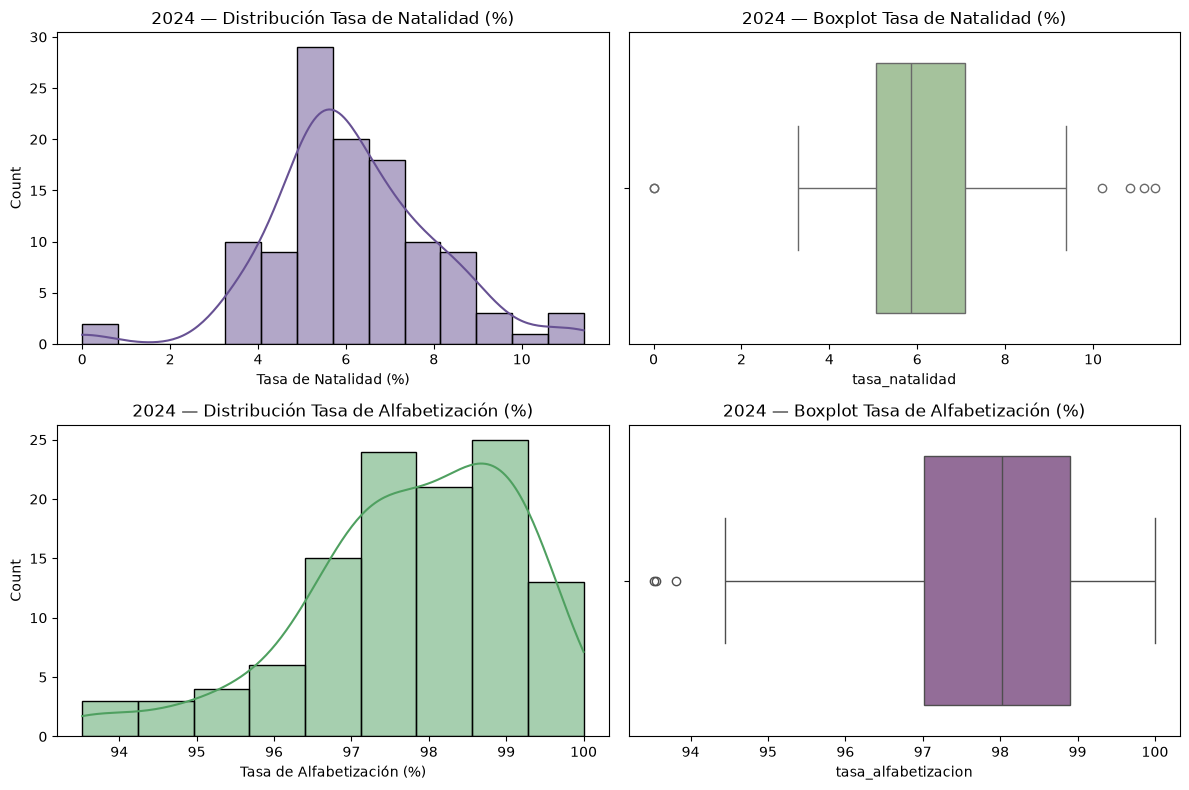

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(gdf24_maipo['tasa_natalidad'], kde=True, color='#675193', ax=axes[0,0])
axes[0,0].set_title('2024 — Distribución Tasa de Natalidad (%)')
axes[0,0].set_xlabel('Tasa de Natalidad (%)')

sns.boxplot(x=gdf24_maipo['tasa_natalidad'], color='#a2c896', ax=axes[0,1])
axes[0,1].set_title('2024 — Boxplot Tasa de Natalidad (%)')

sns.histplot(gdf24_maipo['tasa_alfabetizacion'], kde=True, color='#4fa060', ax=axes[1,0])
axes[1,0].set_title('2024 — Distribución Tasa de Alfabetización (%)')
axes[1,0].set_xlabel('Tasa de Alfabetización (%)')

sns.boxplot(x=gdf24_maipo['tasa_alfabetizacion'], color='#98669f', ax=axes[1,1])
axes[1,1].set_title('2024 — Boxplot Tasa de Alfabetización (%)')

plt.tight_layout()
plt.show()

A nivel de la Provincia del Maipo, la tasa de natalidad 2024 promedia 6,3% (rango 3,3%-11,4%), mientras que la tasa de alfabetización promedia 97,8% (rango 93,5%-99,8%), reflejando un nivel educativo básico consistentemente alto en toda la provincia, con menor dispersión entre zonas que en el caso de natalidad.

A nivel comunal, Buin presenta la natalidad promedio más alta (7,2%) y también la alfabetización más alta (98,3%), concentrando además las zonas censales con los valores más extremos de natalidad de toda la provincia (zonas con tasas sobre 10%, probablemente asociadas a sectores de expansión residencial reciente con población joven). Calera de Tango y Paine, en cambio, muestran los promedios de alfabetización más bajos (96,6% y 96,9% respectivamente), coherente con su carácter más rural y periurbano.

La correlación entre ambas variables a nivel de zona censal es débil y no significativa (r = -0,14; p = 0,16), lo que indica que, contrario a lo que podría esperarse teóricamente (mayor natalidad asociada a menor nivel educativo), en la Provincia del Maipo no existe una relación lineal clara entre natalidad y alfabetización a esta escala territorial. Esto sugiere que las diferencias en alfabetización en la provincia (ya muy alta y homogénea en general) no están determinadas principalmente por la estructura etaria joven de las zonas, sino probablemente por otros factores como acceso histórico a educación, urbanización o composición socioeconómica del hogar — variables no incluidas en este análisis.

---

Procedemos a graficar por separado ambas variables:

C:\Users\katty\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\katty\anaconda3\envs\IDG\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


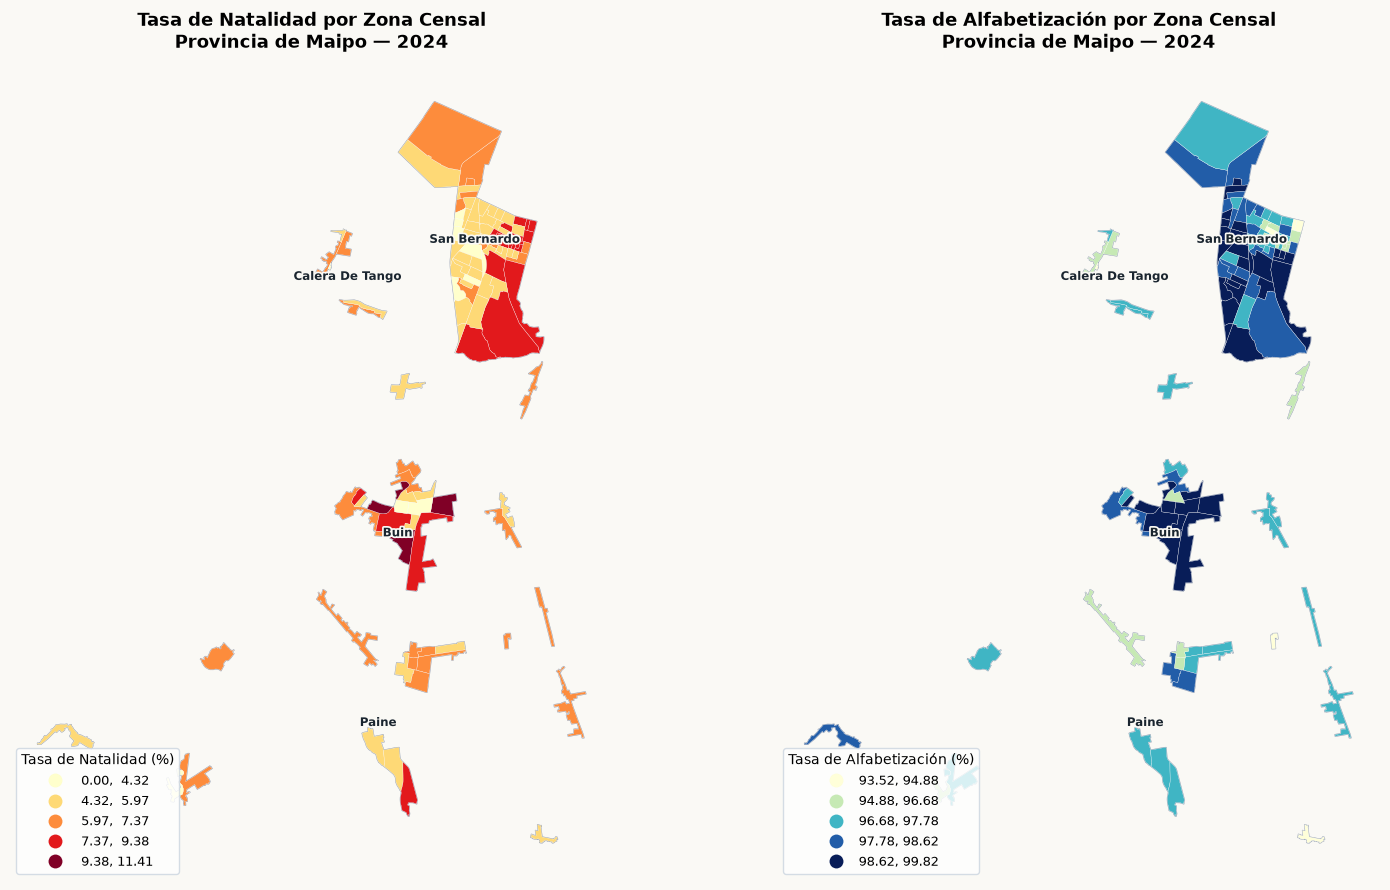

In [42]:
# ==============================================================================
# 0. ASEGURAR COLUMNA GEOMÉTRICA
# ==============================================================================
# Definimos 'SHAPE' como la columna de geometrías activa si no lo está ya
gdf24_maipo = gdf24_maipo.set_geometry('SHAPE')

# ==============================================================================
# 1. GENERAR SILUETA BASE COMUNAL
# ==============================================================================
# Disolvemos agrupando por 'COMUNA' 
comunas_base = gdf24_maipo.dissolve(by='COMUNA', as_index=False)

# Configuración de fondo estilizado
plt.rcParams['figure.facecolor'] = '#FAF9F5'
plt.rcParams['axes.facecolor'] = '#FAF9F5'

# ==============================================================================
# 2. CREACIÓN DE LA FIGURA
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# ==============================================================================
# 3. MAPA IZQUIERDO: TASA DE NATALIDAD (%)
# ==============================================================================
# Capa 1: Molde comunal base (rellena todo el espacio territorial en gris claro)
comunas_base.plot(
    ax=axes[0], 
    color='#E5E5E5', 
    edgecolor='#8D99AE', 
    linewidth=0.8,
    zorder=1
)

# Capa 2: Zonas censales coloreadas por natalidad
gdf24_maipo.plot(
    column='tasa_natalidad', 
    cmap='YlOrRd', 
    scheme='NaturalBreaks', 
    k=5, 
    legend=True, 
    edgecolor='white', 
    linewidth=0.2, 
    ax=axes[0],
    zorder=2,
    legend_kwds={
        'title': 'Tasa de Natalidad (%)', 
        'loc': 'lower left',
        'fontsize': 9,
        'title_fontsize': 10,
        'frameon': True,
        'facecolor': 'white',
        'edgecolor': '#CBD5E0'
    },
    missing_kwds={'color': '#E5E5E5', 'edgecolor': 'white'}
)

axes[0].set_title('Tasa de Natalidad por Zona Censal\nProvincia de Maipo — 2024', fontsize=13, fontweight='bold', pad=12)
axes[0].axis('off')

# ==============================================================================
# 4. MAPA DERECHO: TASA DE ALFABETIZACIÓN (%)
# ==============================================================================
# Capa 1: Molde comunal base
comunas_base.plot(
    ax=axes[1], 
    color='#E5E5E5', 
    edgecolor='#8D99AE', 
    linewidth=0.8,
    zorder=1
)

# Capa 2: Zonas censales coloreadas por alfabetización
gdf24_maipo.plot(
    column='tasa_alfabetizacion', 
    cmap='YlGnBu', 
    scheme='NaturalBreaks', 
    k=5, 
    legend=True, 
    edgecolor='white', 
    linewidth=0.2, 
    ax=axes[1],
    zorder=2,
    legend_kwds={
        'title': 'Tasa de Alfabetización (%)', 
        'loc': 'lower left',
        'fontsize': 9,
        'title_fontsize': 10,
        'frameon': True,
        'facecolor': 'white',
        'edgecolor': '#CBD5E0'
    },
    missing_kwds={'color': '#E5E5E5', 'edgecolor': 'white'}
)

axes[1].set_title('Tasa de Alfabetización por Zona Censal\nProvincia de Maipo — 2024', fontsize=13, fontweight='bold', pad=12)
axes[1].axis('off')

# ==============================================================================
# 5. ETIQUETAS DE COMUNAS 
# ==============================================================================
for _, row in comunas_base.iterrows():
    centroid = row['SHAPE'].centroid
    nombre = str(row['COMUNA']).title()
    for ax in axes:
        ax.text(
            centroid.x, centroid.y, nombre,
            fontsize=8.5, fontweight='bold', color='#1A252F', ha='center', va='center', zorder=3
        ).set_path_effects([pe.withStroke(linewidth=2.5, foreground='#FAF9F5')])

plt.tight_layout()
plt.show()

**Tasa de natalidad**

El mapa de la tasa de natalidad para 2024 muestra nuevamente una distribución espacial heterogénea, con zonas censales que presentan distintos niveles de natalidad estimada. Se identifican sectores con valores elevados y otros con valores considerablemente menores, evidenciando diferencias locales en la dinámica demográfica reciente.

En este mapa aparecen algunas zonas con tasas cercanas a 0 %. Sin embargo, estas corresponden a unidades censales con una población total muy reducida, por lo que el indicador resulta inestable y poco representativo. En términos cartográficos, estos valores extremos afectan la clasificación de colores y deben interpretarse con cautela, ya que responden principalmente al bajo denominador poblacional y no necesariamente a la ausencia real de nacimientos en el territorio.

---
**Tasa de alfabetización**

Para el año 2024, el mapa de alfabetización mantiene un patrón espacial similar al observado en 2017, predominando valores altos en la mayor parte de las zonas censales. Los sectores urbanos continúan concentrando los porcentajes más elevados, mientras que las diferencias entre zonas se mantienen relativamente acotadas.

La estabilidad del patrón espacial sugiere que la alfabetización constituye un indicador con baja variabilidad temporal en el período analizado, manteniéndose niveles elevados en gran parte de la provincia. Esto podría estar asociado a la consolidación de la cobertura educativa y al carácter estructural del indicador.

---

Realizamos un mapa bivariado para las tasas resultantes de los datos del 2024:

C:\Users\katty\AppData\Local\Temp\ipykernel_18052\2727682584.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.92])


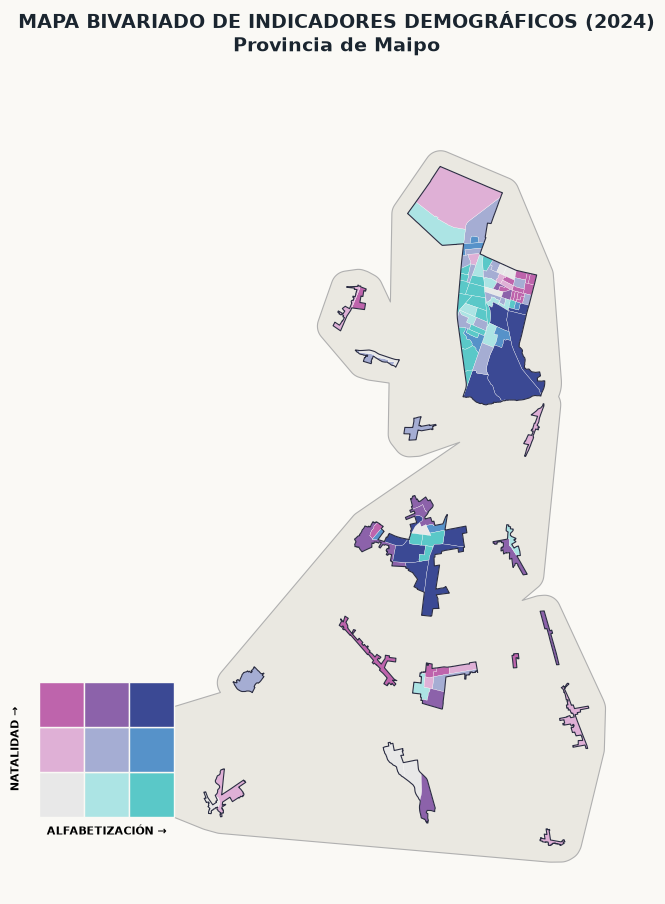

In [59]:
# ==============================================================================
# 3. RENDERIZADO DEL MAPA BIVARIADO 2024 (TÍTULO CORREGIDO)
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 10), facecolor='#FAF9F5')
ax.set_facecolor('#FAF9F5')

xmin, ymin, xmax, ymax = silueta.total_bounds

# Capas
silueta.plot(ax=ax, color='#EAE8E1', edgecolor='#B0B0B0', linewidth=0.8, zorder=1)
gdf24.plot(ax=ax, color=gdf24['color_bivariado'], edgecolor='white', linewidth=0.2, zorder=2)
comunas_base.plot(ax=ax, color='none', edgecolor='#2B2D42', linewidth=0.8, zorder=3)

# Encuadre
ax.set_xlim(xmin - 2000, xmax + 2000)
ax.set_ylim(ymin - 2000, ymax + 2000)
ax.axis('off')

# Leyenda Matricial
ax_leg = fig.add_axes([0.18, 0.12, 0.18, 0.18], facecolor='#FAF9F5')
ax_leg.axis('off')

for i in range(3):
    for j in range(3):
        ax_leg.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color_matrix[i][j], edgecolor='#FAF9F5', lw=1))

ax_leg.set_xlim(-0.5, 3.5)
ax_leg.set_ylim(-0.5, 3.5)
ax_leg.text(1.5, -0.4, 'ALFABETIZACIÓN →', ha='center', fontsize=8, fontweight='bold')
ax_leg.text(-0.4, 1.5, 'NATALIDAD →', ha='right', va='center', rotation=90, fontsize=8, fontweight='bold')

# Título de la figura en la parte superior (fuera del mapa)
fig.suptitle(
    'MAPA BIVARIADO DE INDICADORES DEMOGRÁFICOS (2024)\nProvincia de Maipo', 
    fontsize=14, 
    fontweight='bold', 
    y=0.95,
    color='#1A252F'
)

# Ajuste de márgenes para dar espacio al título arriba y a la leyenda abajo
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

El mapa bivariado de 2024 mantiene un patrón espacial similar al observado en 2017, predominando zonas con alta alfabetización y natalidad baja o media. Las categorías asociadas a baja alfabetización son menos frecuentes y se concentran en sectores específicos de la provincia.

Si bien se observan cambios puntuales en algunas zonas censales, la estructura general del mapa indica una relativa estabilidad en la relación espacial entre ambas variables. Esto sugiere que los procesos educativos y demográficos analizados presentan una continuidad territorial importante entre los censos de 2017 y 2024.

---
Y procedemos a realizar una comparación de la variación de las tasas de natalidad y alfabetización.

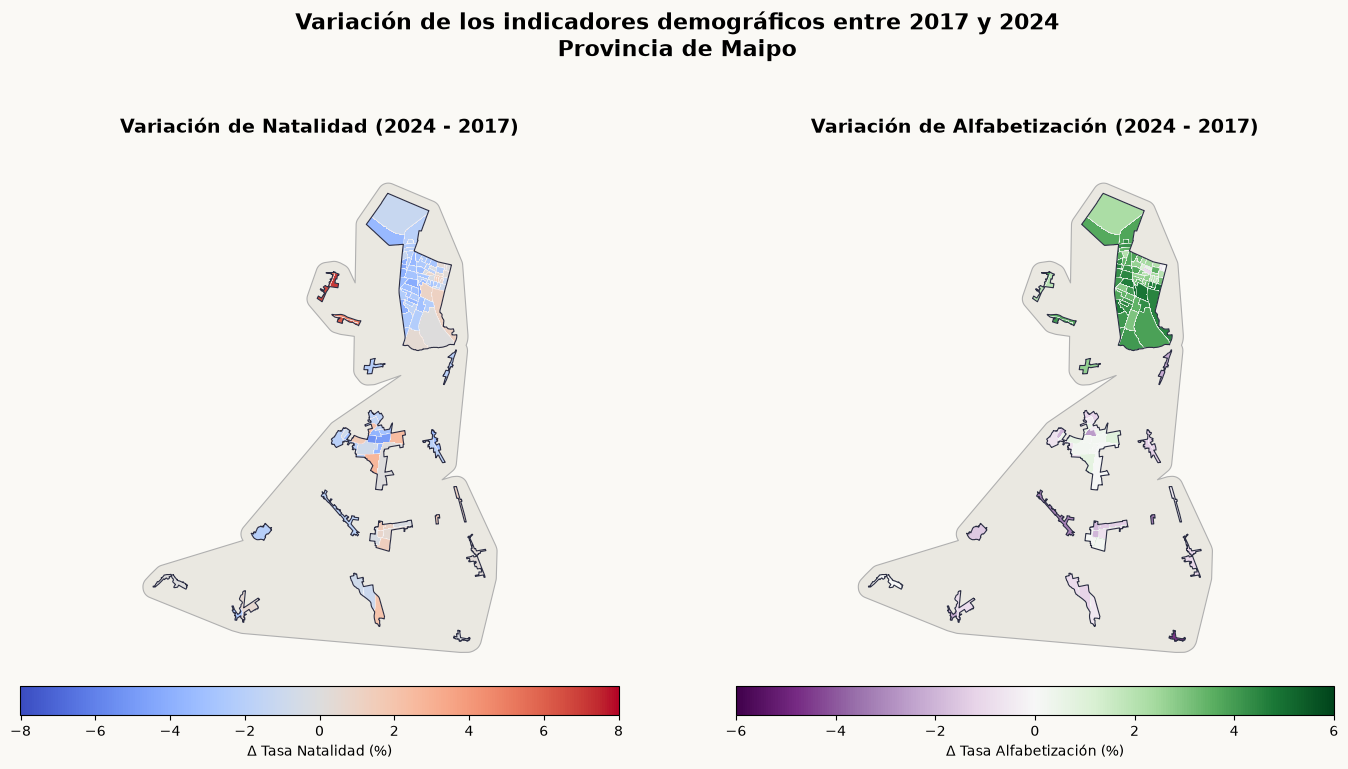

In [61]:
# ==============================================================================
# 0. REPROYECCIÓN A METROS (EPSG:32719 - UTM 19S Chile Central)
# ==============================================================================
TARGET_CRS = "EPSG:32719"

gdf17 = gdf_maipo.copy()
gdf24 = gdf24_maipo.copy()

if gdf17.crs is None: gdf17.set_crs(epsg=4326, inplace=True)
if gdf24.crs is None: gdf24.set_crs(epsg=4326, inplace=True)

gdf17 = gdf17.to_crs(TARGET_CRS)
gdf24 = gdf24.to_crs(TARGET_CRS)

# ==============================================================================
# 1. SILUETA BASE EN METROS
# ==============================================================================
comunas_base = gdf24.dissolve(by='COMUNA', as_index=False)
comunas_base['SHAPE_MOLDE'] = comunas_base.geometry.convex_hull.buffer(1000)
silueta = comunas_base.set_geometry('SHAPE_MOLDE').dissolve()

# ==============================================================================
# 2. UNIÓN Y CÁLCULO DE DELTAS
# ==============================================================================
col_id = 'CUT'  # Reemplaza por el código censal común si difiere

gdf_delta = gdf24.merge(
    gdf17[[col_id, 'tasa_natalidad', 'tasa_alfabetizacion']], 
    on=col_id, 
    suffixes=('_2024', '_2017')
)

gdf_delta['variacion_natalidad'] = gdf_delta['tasa_natalidad_2024'] - gdf_delta['tasa_natalidad_2017']
gdf_delta['variacion_alfabetizacion'] = gdf_delta['tasa_alfabetizacion_2024'] - gdf_delta['tasa_alfabetizacion_2017']

# ==============================================================================
# 3. GRAFICAR MAPAS DE DELTA 
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='#FAF9F5')

xmin, ymin, xmax, ymax = silueta.total_bounds

# --- MAPA 1: VARIACIÓN NATALIDAD ---
axes[0].set_facecolor('#FAF9F5')
silueta.plot(ax=axes[0], color='#EAE8E1', edgecolor='#B0B0B0', linewidth=0.8, zorder=1)

gdf_delta.plot(
    column='variacion_natalidad',
    cmap='coolwarm',
    legend=True,
    edgecolor='white',
    linewidth=0.2,
    ax=axes[0],
    zorder=2,
    legend_kwds={
        'label': 'Δ Tasa Natalidad (%)', 
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    }
)

comunas_base.plot(ax=axes[0], color='none', edgecolor='#2B2D42', linewidth=0.8, zorder=3)
axes[0].set_xlim(xmin - 2000, xmax + 2000)
axes[0].set_ylim(ymin - 2000, ymax + 2000)
axes[0].set_title('Variación de Natalidad (2024 - 2017)', fontsize=14, fontweight='bold', pad=10)
axes[0].axis('off')

# --- MAPA 2: VARIACIÓN ALFABETIZACIÓN ---
axes[1].set_facecolor('#FAF9F5')
silueta.plot(ax=axes[1], color='#EAE8E1', edgecolor='#B0B0B0', linewidth=0.8, zorder=1)

gdf_delta.plot(
    column='variacion_alfabetizacion',
    cmap='PRGn',
    legend=True,
    edgecolor='white',
    linewidth=0.2,
    ax=axes[1],
    zorder=2,
    legend_kwds={
        'label': 'Δ Tasa Alfabetización (%)',  
        'orientation': 'horizontal',
        'shrink': 0.7,
        'pad': 0.02
    }
)

comunas_base.plot(ax=axes[1], color='none', edgecolor='#2B2D42', linewidth=0.8, zorder=3)
axes[1].set_xlim(xmin - 2000, xmax + 2000)
axes[1].set_ylim(ymin - 2000, ymax + 2000)
axes[1].set_title('Variación de Alfabetización (2024 - 2017)', fontsize=14, fontweight='bold', pad=10)
axes[1].axis('off')

plt.suptitle('Variación de los indicadores demográficos entre 2017 y 2024\nProvincia de Maipo', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Este mapa representa la diferencia entre la tasa de natalidad estimada registrada en 2024 y la observada en 2017 para cada zona censal. Los valores positivos indican un aumento de la tasa de natalidad respecto del período anterior, mientras que los valores negativos representan una disminución.

Se observa que la provincia presenta un comportamiento heterogéneo, coexistiendo zonas censales donde la natalidad aumentó con otras donde disminuyó. Los cambios no siguen un patrón espacial claramente definido, lo que sugiere que la evolución de este indicador responde a dinámicas locales asociadas a la composición de la población y a las características demográficas de cada sector.

**Variación de la tasa de natalidad (2024–2017)**

Este mapa representa la diferencia entre la tasa de natalidad estimada registrada en 2024 y la observada en 2017 para cada zona censal. Los valores positivos indican un aumento de la tasa de natalidad respecto del período anterior, mientras que los valores negativos representan una disminución.

Se observa que la provincia presenta un comportamiento heterogéneo, coexistiendo zonas censales donde la natalidad aumentó con otras donde disminuyó. Los cambios no siguen un patrón espacial claramente definido, lo que sugiere que la evolución de este indicador responde a dinámicas locales asociadas a la composición de la población y a las características demográficas de cada sector.

---
**Variación de la tasa de alfabetización (2024–2017)**

El mapa muestra la diferencia entre la tasa de alfabetización registrada en 2024 y la correspondiente al Censo 2017. Los valores positivos representan zonas donde la alfabetización aumentó, mientras que los valores negativos indican una disminución del indicador.

En general, las variaciones observadas son de baja magnitud, evidenciando que la alfabetización se mantuvo relativamente estable durante el período analizado. Las diferencias identificadas en algunas zonas censales podrían estar asociadas a cambios en la composición de la población o a procesos migratorios, más que a transformaciones significativas en el acceso a la educación.

## 6. Discusión y conclusiones

Una de las principales limitaciones del estudio corresponde a la estimación de la tasa de natalidad a partir de la población de 0 a 1 año registrada por los censos. Si bien esta aproximación permite construir un indicador comparable utilizando únicamente información censal, no representa exactamente el número de nacidos vivos, ya que puede verse afectada por la mortalidad infantil y por procesos migratorios ocurridos antes del levantamiento censal.

Además, se identificaron algunas zonas censales con poblaciones muy reducidas, donde el cálculo de tasas produjo valores extremos o poco representativos. Estos casos evidencian la sensibilidad de los indicadores cuando el denominador es pequeño, por lo que sus resultados deben interpretarse con cautela.

Finalmente, aunque los mapas bivariados constituyen una herramienta útil para explorar relaciones espaciales entre variables, estos no permiten establecer relaciones de causalidad, sino únicamente identificar patrones territoriales que pueden orientar análisis posteriores.

El análisis espacial realizado permitió identificar que la Provincia del Maipo presenta un comportamiento diferenciado para las variables estudiadas. Mientras la tasa de alfabetización exhibe una distribución relativamente homogénea y altos valores en la mayor parte de las zonas censales, la tasa de natalidad estimada muestra una mayor variabilidad espacial, evidenciando diferencias locales entre los distintos sectores de la provincia.

Los mapas bivariados permitieron analizar la distribución conjunta de ambos indicadores, observándose un predominio de zonas con alta alfabetización y tasas de natalidad bajas o medias. No obstante, también se identificaron sectores donde estas variables presentan combinaciones distintas, lo que indica que la relación entre ambas no es uniforme y que la natalidad puede estar influida por otros factores demográficos, sociales y territoriales que no fueron considerados en este estudio.

La comparación entre los censos de 2017 y 2024 evidenció una alta estabilidad espacial de la tasa de alfabetización, mientras que la tasa de natalidad presentó cambios más heterogéneos entre las zonas censales. Aun así, no se observaron transformaciones que modificaran significativamente el patrón territorial general de la provincia, lo que sugiere una continuidad en la distribución espacial de ambos indicadores durante el período analizado.

Desde el punto de vista metodológico, el uso de mapas bivariados permitió integrar dos variables en una misma representación cartográfica, facilitando la identificación de patrones espaciales y zonas de interés que difícilmente podrían reconocerse mediante mapas univariados. Asimismo, la comparación temporal aportó una visión más completa de la evolución territorial de los indicadores entre ambos censos.

Finalmente, es importante considerar que la tasa de natalidad fue estimada utilizando la población de 0 a 1 año registrada en los censos, debido a la ausencia de información sobre nacidos vivos en la base de datos utilizada. Si bien esta aproximación permitió realizar un análisis comparable entre ambos períodos, los resultados deben interpretarse considerando las limitaciones asociadas a este procedimiento, especialmente en aquellas zonas censales con poblaciones reducidas.

En futuras investigaciones sería interesante y pertinente incorporar otras variables sociodemográficas, como el nivel de ingresos, la escolaridad o el grado de urbanización, con el propósito de profundizar en los factores que influyen sobre la distribución espacial de la natalidad y la alfabetización. Asimismo, el uso de registros administrativos, como las estadísticas vitales, permitiría obtener estimaciones más precisas de la natalidad y complementar el análisis realizado a partir de la información censal.